# Numerical tools

**Table of contents**<a id='toc0_'></a>    
- 1. [Imports](#toc1_)    
- 2. [Settings](#toc2_)    
- 3. [Grids](#toc3_)    
- 4. [Interpolation](#toc4_)    
  - 4.1. [Example](#toc4_1_)    
  - 4.2. [Many points at once](#toc4_2_)    
- 5. [Maximization](#toc5_)    
  - 5.1. [Grid search](#toc5_1_)    
  - 5.2. [Golden section search](#toc5_2_)    
- 6. [Collected in tools.py](#toc6_)    

<!-- vscode-jupyter-toc-config
	numbering=true
	anchor=true
	flat=false
	minLevel=2
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

**Content:** The three numerical problems behind value function iteration: putting the state space on a *grid*,
evaluating a function *between* grid points, and *maximizing* over a choice.

**Note:** Everything is plain `numpy`. The functions built here are collected in `tools.py` and reused in the later notebooks.

## 1. <a id='toc1_'></a>[Imports](#toc0_)

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt

## 2. <a id='toc2_'></a>[Settings](#toc0_)

In [2]:
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
plt.rcParams.update({'axes.grid':True,'grid.color':'black','grid.alpha':'0.25','grid.linestyle':'--'})
plt.rcParams.update({'font.size':14})

## 3. <a id='toc3_'></a>[Grids](#toc0_)

A state variable that lives on a continuum has to be replaced by a finite set of points,

$$
a_t \in \mathcal{G}_a = \{a^0,a^1,\dots,a^{\#_a-1}\}, \quad a^0 = \underline{a}
$$

The obvious choice is equal spacing. It is a bad one. The consumption function bends sharply near the borrowing
constraint and is close to linear far from it, so we want points where the curvature is.

In [3]:
def equilogspace(x_min,x_max,n):
    """ grid from x_min to x_max, (close to) equidistant in logs """

    pivot = np.abs(x_min) + 0.25
    grid = np.geomspace(x_min+pivot,x_max+pivot,n) - pivot
    grid[0] = x_min

    return grid

Compare the two:

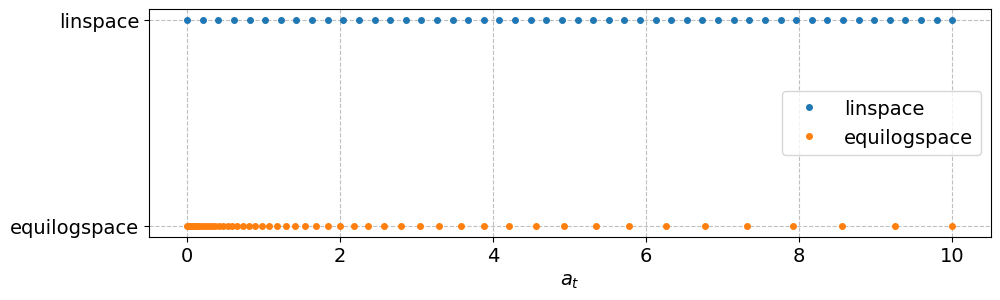

In [4]:
a_max = 10.0
Na = 50

a_grid_lin = np.linspace(0.0,a_max,Na)
a_grid_log = equilogspace(0.0,a_max,Na)

fig = plt.figure(figsize=(10,3))
ax = fig.add_subplot(1,1,1)
ax.plot(a_grid_lin,np.ones(Na),'o',ms=4,label='linspace')
ax.plot(a_grid_log,np.zeros(Na),'o',ms=4,label='equilogspace')
ax.set_yticks([0,1])
ax.set_yticklabels(['equilogspace','linspace'])
ax.set_xlabel('$a_t$')
ax.legend(loc='center right',facecolor='white',frameon=True)
fig.tight_layout(pad=0.5)
fig.savefig('figs/grids.pdf')

In [5]:
print(f'first 5 points, linspace:      {np.round(a_grid_lin[:5],3)}')
print(f'first 5 points, equilogspace: {np.round(a_grid_log[:5],3)}')

first 5 points, linspace:      [0.    0.204 0.408 0.612 0.816]
first 5 points, equilogspace: [0.    0.02  0.041 0.064 0.089]


## 4. <a id='toc4_'></a>[Interpolation](#toc0_)

To solve dynamic optimization problems we need to evaluate a function at points that are *not* on the grid.

**Inputs:**

1. Sorted vector of known points (grid vector), $G = \{G_i\}_{i=0}^{n-1}$.
2. Vector of known values (at these points), $F = \{F_i = f(G_i)\}_{i=0}^{n-1}$.
3. A new point, `x`, not in $G$.

**Algorithm:** `linear_interpolate()`
1. Determine `i`  such that

$$
G_i \leq x < G_{i+1}
$$

2. Compute interpolated value by

$$
y =  F_{i} + \frac{F_{i+1}-F_{i}}{G_{i+1}-G_{i}}(x-G_{i})
$$

**Extrapolation:**

1. Below where $x < G_1$ use $i = 0$.

$$
y =  F_{0} + \frac{F_{1}-F_{0}}{G_{1}-G_{0}}(x-G_{0})
$$

2. Above where $x > G_{n-2}$ (use $i = n-2$)

$$
y =  F_{n-2} + \frac{F_{n-1}-F_{n-2}}{G_{n-1}-G_{n-2}}(x-G_{n-2})
$$

In [6]:
def linear_interpolate(G,F,x):
    """ linear interpolation (and extrapolation) of f at the single point x """

    assert len(G) == len(F)
    n = len(G)

    # a. find index in known points
    if x < G[1]: # extrapolation below

        i = 0

    elif x > G[-2]: # extrapolation above

        i = n-2

    else: # true interpolation

        i = 0
        while x >= G[i+1] and i < n-1:
            i += 1

        assert x >= G[i]
        assert x < G[i+1]

    # b. interpolate
    slope = (F[i+1]-F[i])/(G[i+1]-G[i])

    return F[i] + slope*(x-G[i])

### 4.1. <a id='toc4_1_'></a>[Example](#toc0_)

Consider the following function and known points:

In [7]:
f = lambda x: (x-3)**3 - 3*x**2 + 5*x

G = np.linspace(-5,10,12)
F = f(G)

True function values at fine grid:

In [8]:
grid = np.linspace(-6,11,500) # 500 makes it 'fine'
F_true = f(grid)

Simple test:

x = -2.3 -> true = -176.2, interpolated = -177.0
x =  4.9 -> true =  -40.7, interpolated =  -39.5
x =  7.5 -> true =  -40.1, interpolated =  -37.2
x =  9.1 -> true =   24.1, interpolated =   30.6


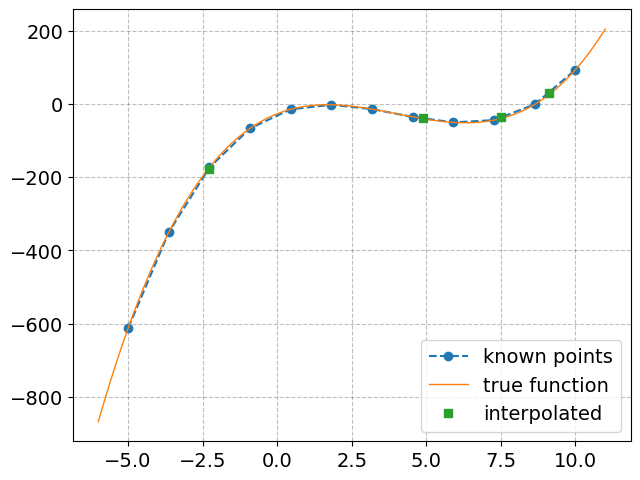

In [9]:
X = [-2.3,4.9,7.5,9.1]
F_approx = []
for x in X:
    y = linear_interpolate(G,F,x)
    F_approx.append(y)
    print(f'x = {x:4.1f} -> true = {f(x):6.1f}, interpolated = {y:6.1f}')

fig = plt.figure()
ax = fig.add_subplot(1,1,1)
ax.plot(G,F,'--o',label='known points')
ax.plot(grid,F_true,'-',lw=1,label='true function')
ax.plot(X,F_approx,'s',lw=1,label='interpolated')
ax.legend(loc='lower right',facecolor='white',frameon=True)
fig.tight_layout(pad=0.5)
fig.savefig('figs/linear_interpolation.pdf')

**Task:** Change the number of *known* points in the cell below and see what happens.

### 4.2. <a id='toc4_2_'></a>[Many points at once](#toc0_)

The loop above is fine for one point, but the solver evaluates the value function at every grid point on
every iteration. `np.searchsorted` does the same search for a whole array in one call.

In [10]:
def linear_interpolate_vec(G,F,x):
    """ linear interpolation (and extrapolation) of f at every point in the array x """

    # a. locate each x between two known points
    i = np.searchsorted(G,x,side='right') - 1
    i = np.clip(i,0,G.size-2)

    # b. interpolate
    slope = (F[i+1]-F[i])/(G[i+1]-G[i])

    return F[i] + slope*(x-G[i])

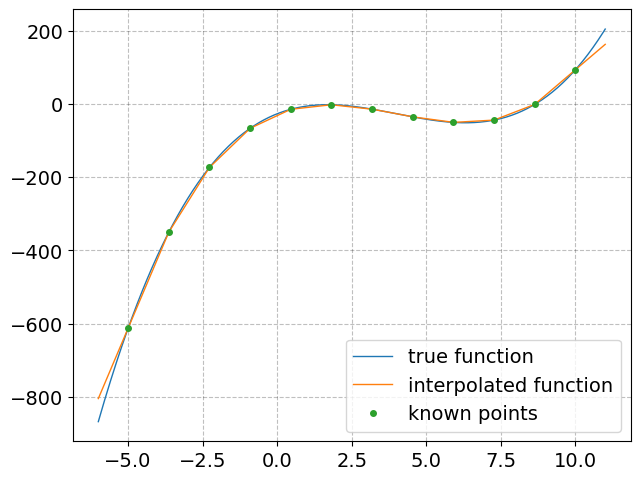

In [11]:
G_coarse = np.linspace(-5,10,12)
F_coarse = f(G_coarse)

fig = plt.figure()
ax = fig.add_subplot(1,1,1)
ax.plot(grid,F_true,'-',lw=1,label='true function')
ax.plot(grid,linear_interpolate_vec(G_coarse,F_coarse,grid),'-',lw=1,label='interpolated function')
ax.plot(G_coarse,F_coarse,'o',ms=4,label='known points')
ax.legend(loc='lower right',facecolor='white',frameon=True)
fig.tight_layout(pad=0.5)

**Note:**

1. Linear interpolation works best when the function does not curve too much.
2. *Extrapolation* is much worse than *interpolation*.
3. Multiple dimensions: same principle.

The two versions agree:

In [12]:
assert np.allclose([linear_interpolate(G,F,x) for x in X],linear_interpolate_vec(G,F,np.array(X)))
print('same answer')

same answer


## 5. <a id='toc5_'></a>[Maximization](#toc0_)

Value function iteration needs, at each grid point, the solution to

$$
\max_{c_t} \, u(c_t) + \beta \breve{v}_{t+1}(m_t-c_t)
$$

The objective is *concave* in $c_t$ but we only know it through interpolation, so it is not smooth and we cannot
differentiate it. We need a derivative-free maximizer.

Test it on a problem where the answer is known, a quadratic on an interval,

$$
\max_{x \in [0,\bar{x}]} \, -(x-x^{\star})^2
$$

with solution $\hat{x} = \min(x^{\star},\bar{x})$.

In [13]:
def objective(x,peak):
    """ concave quadratic with unconstrained maximum at peak """

    return -(x-peak)**2

peak = 3.0
x_max = 5.0

### 5.1. <a id='toc5_1_'></a>[Grid search](#toc0_)

The crudest method: try many values and keep the best. Robust, but the accuracy is the spacing of the trial grid.

In [14]:
for Nx in [10,100,1_000,10_000]:

    x_trials = np.linspace(0.0,x_max,Nx)
    x_best = x_trials[np.argmax(objective(x_trials,peak))]
    print(f'{Nx:6d} trial points -> x = {x_best:.8f}, error = {np.abs(x_best-peak):.2e}')

    10 trial points -> x = 2.77777778, error = 2.22e-01
   100 trial points -> x = 2.97979798, error = 2.02e-02
  1000 trial points -> x = 2.99799800, error = 2.00e-03
 10000 trial points -> x = 2.99979998, error = 2.00e-04


### 5.2. <a id='toc5_2_'></a>[Golden section search](#toc0_)

Much better for a concave objective. Keep a bracket $[a,b]$ known to contain the maximum, put two interior
points in it, and throw away the part of the bracket that cannot contain the maximum. The golden ratio is the
spacing that lets one of the two interior points be reused.

The bracket shrinks by a factor $1/\varphi \approx 0.618$ per iteration, so 50 iterations get us from a bracket of
width 1 to $10^{-11}$, whatever the function looks like.

In [15]:
def golden_section_search(objective,lower,upper,args=(),n_iter=50):
    """ maximize a concave objective on [lower,upper], vectorized over the bounds """

    inv_phi = (np.sqrt(5)-1)/2

    a = np.asarray(lower,dtype=float).copy()
    b = np.asarray(upper,dtype=float).copy()

    for _ in range(n_iter):

        # a. two interior points
        c = b - inv_phi*(b-a)
        d = a + inv_phi*(b-a)

        # b. keep the bracket containing the maximum
        keep_lower = objective(c,*args) > objective(d,*args)
        b = np.where(keep_lower,d,b)
        a = np.where(keep_lower,a,c)

    return (a+b)/2

In [16]:
x_hat = golden_section_search(objective,0.0,x_max,args=(peak,))
print(f'golden section -> x = {x_hat:.8f}, error = {np.abs(x_hat-peak):.2e}')

golden section -> x = 3.00000000, error = 1.78e-11


The reason to prefer this over a fancier optimizer is the first two arguments of the function: `lower` and `upper`
can be *arrays*. Every grid point takes the same number of iterations, so the whole state space is solved at once
with no Python loop.

Below the upper bound varies. When it binds the maximizer sits at the corner, exactly like consumption at the
borrowing constraint later on.

<>:7: SyntaxWarning: invalid escape sequence '\m'
<>:9: SyntaxWarning: invalid escape sequence '\h'
<>:7: SyntaxWarning: invalid escape sequence '\m'
<>:9: SyntaxWarning: invalid escape sequence '\h'
/var/folders/hn/dsqvtr1n09z9k135wwh_g7280000gn/T/ipykernel_4508/941422824.py:7: SyntaxWarning: invalid escape sequence '\m'
  ax.plot(x_max_vec,np.minimum(peak,x_max_vec),'--',lw=1.5,label='$\min(x^{\star},\\bar{x})$')
/var/folders/hn/dsqvtr1n09z9k135wwh_g7280000gn/T/ipykernel_4508/941422824.py:9: SyntaxWarning: invalid escape sequence '\h'
  ax.set_ylabel('maximizer, $\hat{x}$')


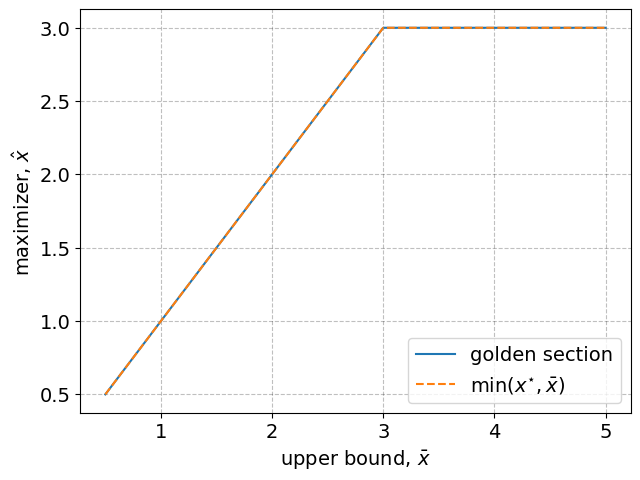

In [17]:
x_max_vec = np.linspace(0.5,5.0,1_000)
x_hat_vec = golden_section_search(objective,np.zeros(x_max_vec.size),x_max_vec,args=(peak,))

fig = plt.figure()
ax = fig.add_subplot(1,1,1)
ax.plot(x_max_vec,x_hat_vec,'-',lw=1.5,label='golden section')
ax.plot(x_max_vec,np.minimum(peak,x_max_vec),'--',lw=1.5,label='$\min(x^{\star},\\bar{x})$')
ax.set_xlabel('upper bound, $\\bar{x}$')
ax.set_ylabel('maximizer, $\hat{x}$')
ax.legend(loc='lower right',facecolor='white',frameon=True)
fig.tight_layout(pad=0.5)

In [18]:
%timeit golden_section_search(objective,np.zeros(x_max_vec.size),x_max_vec,args=(peak,))

320 μs ± 6.24 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


## 6. <a id='toc6_'></a>[Collected in tools.py](#toc0_)

All four functions are in `tools.py`, together with `rouwenhorst` and `find_ergodic` for the income process
in notebook 03. The later notebooks import from there instead of redefining them.

In [19]:
from tools import equilogspace, linear_interpolate, linear_interpolate_vec, golden_section_search

print('ok')

ok
